In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("HR_Analytacis.csv")
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


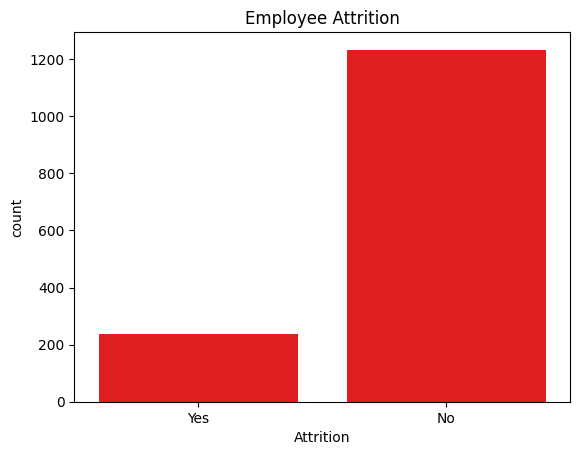

In [6]:
#Attrition Distribution

sns.countplot(x='Attrition', data=df,color='Red')
plt.title("Employee Attrition")
plt.show()

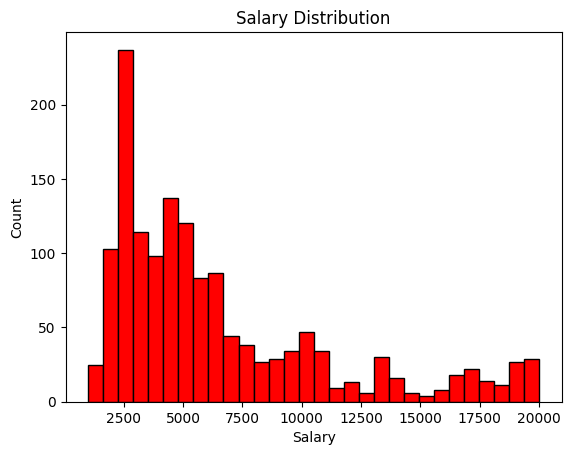

In [ ]:
#Salary Distribution

plt.hist(df['MonthlyIncome'], bins=30,color='red', edgecolor='black')
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Count")
plt.show()

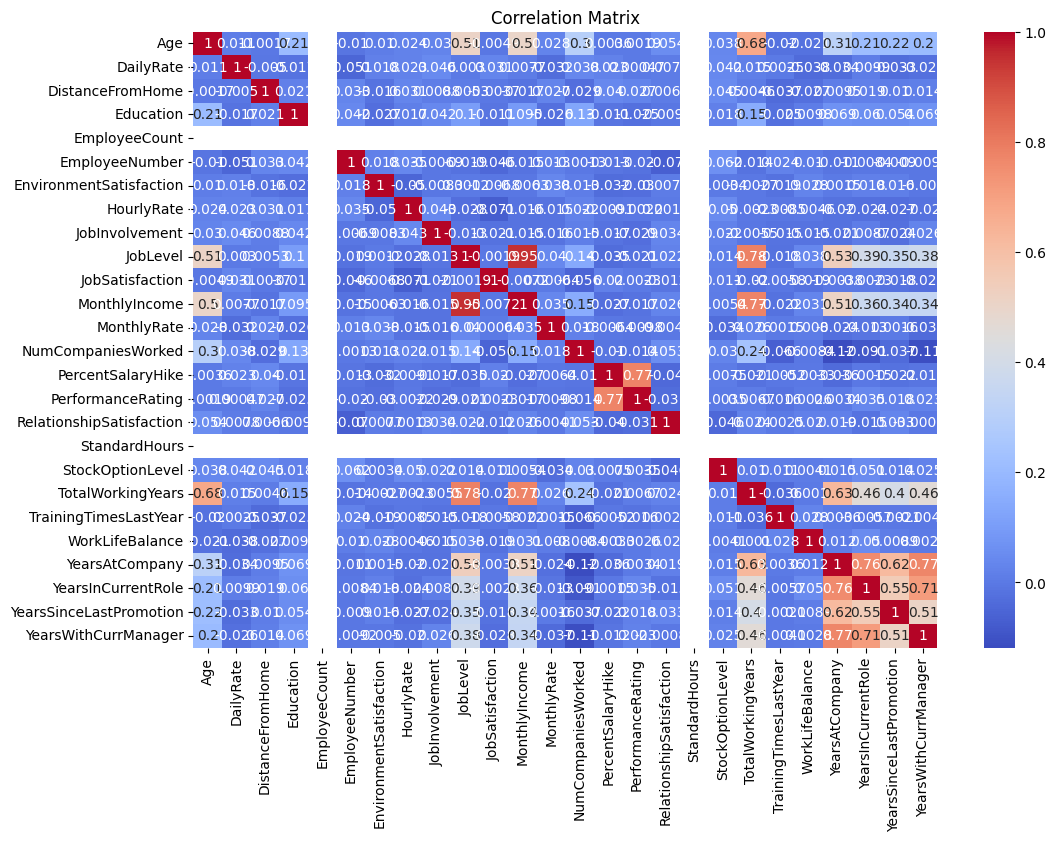

In [10]:
#Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

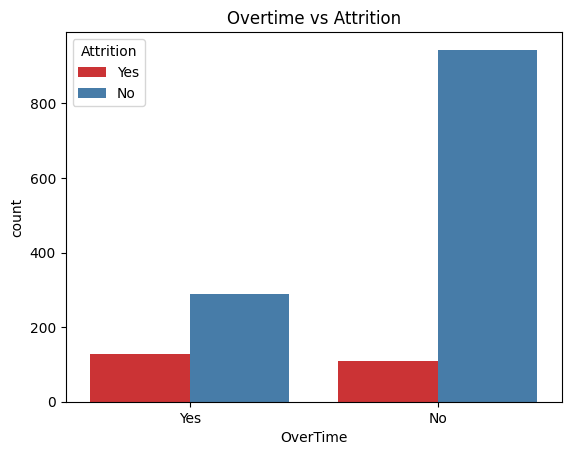

In [21]:
#Overtime vs Attrition

sns.countplot(x='OverTime',color='red',
              hue='Attrition', palette='Set1',
              data=df)

plt.title("Overtime vs Attrition")
plt.show()

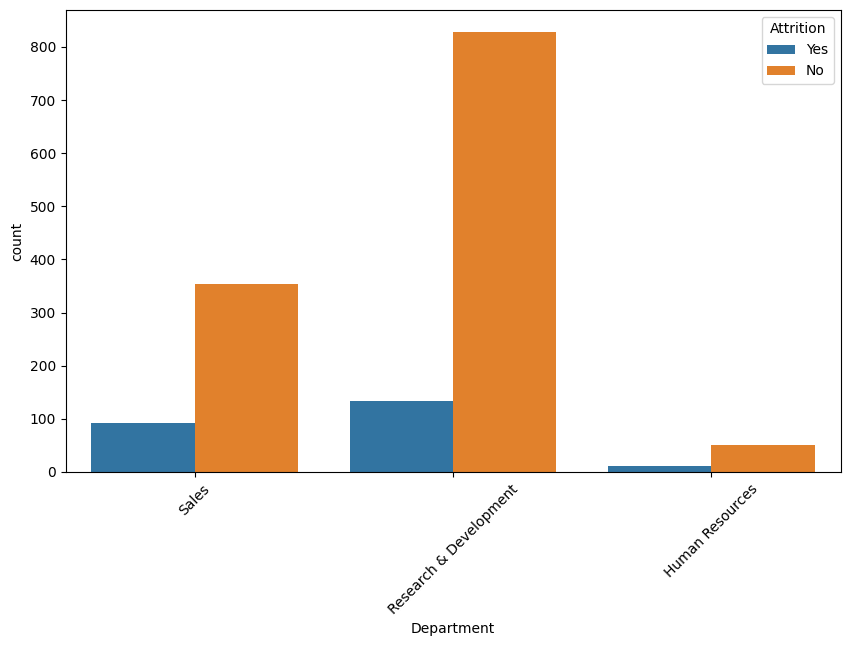

In [22]:
#Department-wise Attrition

plt.figure(figsize=(10,6))

sns.countplot(x='Department',
              hue='Attrition',
              data=df)

plt.xticks(rotation=45)
plt.show()

In [24]:
#advanced feature engineering

df['experience_level'] = pd.cut(
    df['YearsAtCompany'],
    bins=[0,2,5,10,40],
    labels=['Fresher','Junior','Mid','Senior']
)

In [27]:
df['salary_category'] = pd.cut(
    df['MonthlyIncome'],
    bins=[0,3000,7000,15000,50000],
    labels=['Low','Medium','High','Very High']
)

In [29]:
df['OverTime'] = df['OverTime'].map({
    'Y':1,
    'N':0
})

Advanced statistical analysis

In [ ]:
#Average Salary by Department

print(df.groupby('Department')['MonthlyIncome'].mean())

Department
Human Resources           6654.507937
Research & Development    6281.252862
Sales                     6959.172646
Name: MonthlyIncome, dtype: float64


In [31]:
#Attrition Percentage

attrition_rate = (
    df['Attrition'].value_counts(normalize=True) * 100
)

print(attrition_rate)

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


In [32]:
#Crosstab Analysis

print(pd.crosstab(df['Department'],
                  df['Attrition']))

Attrition                No  Yes
Department                      
Human Resources          51   12
Research & Development  828  133
Sales                   354   92


4. Machine Learning (Attrition Prediction)

Goal:

Predict whether an employee will leave the company.

In [34]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
#Check Categorical Columns

print(df.select_dtypes(include='object').columns)

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18'],
      dtype='object')


In [49]:
#Apply Label Encoding

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [50]:
#Verify Conversion

print(df.head())

   Age  Attrition  BusinessTravel  DailyRate  Department  DistanceFromHome  \
0   41          1               2       1102           2                 1   
1   49          0               1        279           1                 8   
2   37          1               2       1373           1                 2   
3   33          0               1       1392           1                 3   
4   27          0               2        591           1                 2   

   Education  EducationField  EmployeeCount  EmployeeNumber  ...  \
0          2               1              1               1  ...   
1          1               1              1               2  ...   
2          2               4              1               4  ...   
3          4               1              1               5  ...   
4          1               3              1               7  ...   

   StockOptionLevel  TotalWorkingYears  TrainingTimesLastYear  \
0                 0                  8                   

In [ ]:
#Split Features & Target

X = df.drop('Attrition', axis=1)

y = df['Attrition']

In [52]:
#Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [58]:
df = pd.get_dummies(df, drop_first=True)

In [60]:
print(df.head())

   Age  Attrition  BusinessTravel  DailyRate  Department  DistanceFromHome  \
0   41          1               2       1102           2                 1   
1   49          0               1        279           1                 8   
2   37          1               2       1373           1                 2   
3   33          0               1       1392           1                 3   
4   27          0               2        591           1                 2   

   Education  EducationField  EmployeeCount  EmployeeNumber  ...  \
0          2               1              1               1  ...   
1          1               1              1               2  ...   
2          2               4              1               4  ...   
3          4               1              1               5  ...   
4          1               3              1               7  ...   

   YearsAtCompany  YearsInCurrentRole  YearsSinceLastPromotion  \
0               6                   4                   

In [64]:
df = pd.get_dummies(df, drop_first=True)

In [65]:
print(df.dtypes)

Age                            int64
Attrition                      int64
BusinessTravel                 int64
DailyRate                      int64
Department                     int64
DistanceFromHome               int64
Education                      int64
EducationField                 int64
EmployeeCount                  int64
EmployeeNumber                 int64
EnvironmentSatisfaction        int64
Gender                         int64
HourlyRate                     int64
JobInvolvement                 int64
JobLevel                       int64
JobRole                        int64
JobSatisfaction                int64
MaritalStatus                  int64
MonthlyIncome                  int64
MonthlyRate                    int64
NumCompaniesWorked             int64
Over18                         int64
OverTime                     float64
PercentSalaryHike              int64
PerformanceRating              int64
RelationshipSatisfaction       int64
StandardHours                  int64
S

In [67]:
X = df.drop('Attrition', axis=1)

y = df['Attrition']

In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [69]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

c:\Users\shali\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\extmath.py:1137: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
c:\Users\shali\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\extmath.py:1142: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
c:\Users\shali\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\extmath.py:1162: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [70]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [71]:
print(df.isnull().sum())

Age                             0
Attrition                       0
BusinessTravel                  0
DailyRate                       0
Department                      0
DistanceFromHome                0
Education                       0
EducationField                  0
EmployeeCount                   0
EmployeeNumber                  0
EnvironmentSatisfaction         0
Gender                          0
HourlyRate                      0
JobInvolvement                  0
JobLevel                        0
JobRole                         0
JobSatisfaction                 0
MaritalStatus                   0
MonthlyIncome                   0
MonthlyRate                     0
NumCompaniesWorked              0
Over18                          0
OverTime                     1470
PercentSalaryHike               0
PerformanceRating               0
RelationshipSatisfaction        0
StandardHours                   0
StockOptionLevel                0
TotalWorkingYears               0
TrainingTimesL

In [73]:
print(df['OverTime'].isnull().sum())

1470


In [78]:
print(df['OverTime'].unique())

[nan]


In [79]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

In [80]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [81]:
df = pd.get_dummies(df, drop_first=True)

In [83]:
df.drop('OverTime', axis=1, inplace=True)

In [76]:
print(df['OverTime'].isnull().sum())

1470


In [84]:
print(df.isnull().sum().sum())

0


In [85]:
df = df.astype(int)

In [86]:
X = df.drop('Attrition', axis=1)

y = df['Attrition']

In [87]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [88]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [89]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [90]:
y_pred = model.predict(X_test)

In [91]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8809523809523809


In [92]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[253   2]
 [ 33   6]]


In [93]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.99      0.94       255
           1       0.75      0.15      0.26        39

    accuracy                           0.88       294
   macro avg       0.82      0.57      0.60       294
weighted avg       0.87      0.88      0.85       294



In [94]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

In [95]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test, y_pred))

0.8707482993197279


In [96]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators':[100,200],
    'max_depth':[5,10,15]
}

grid = GridSearchCV(
    RandomForestClassifier(),
    params,
    cv=5
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': 15, 'n_estimators': 200}


In [97]:
importance = rf.feature_importances_

feature_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

print(feature_df.sort_values(
    by='Importance',
    ascending=False
))

                      Feature  Importance
17              MonthlyIncome    0.090027
0                         Age    0.055910
2                   DailyRate    0.051192
18                MonthlyRate    0.050970
8              EmployeeNumber    0.048593
26          TotalWorkingYears    0.048561
11                 HourlyRate    0.046292
4            DistanceFromHome    0.043326
29             YearsAtCompany    0.039539
19         NumCompaniesWorked    0.038213
25           StockOptionLevel    0.037777
21          PercentSalaryHike    0.035423
32       YearsWithCurrManager    0.034718
14                    JobRole    0.032032
30         YearsInCurrentRole    0.029012
15            JobSatisfaction    0.027887
16              MaritalStatus    0.027608
31    YearsSinceLastPromotion    0.027012
27      TrainingTimesLastYear    0.025299
9     EnvironmentSatisfaction    0.024496
12             JobInvolvement    0.023874
6              EducationField    0.022108
28            WorkLifeBalance    0

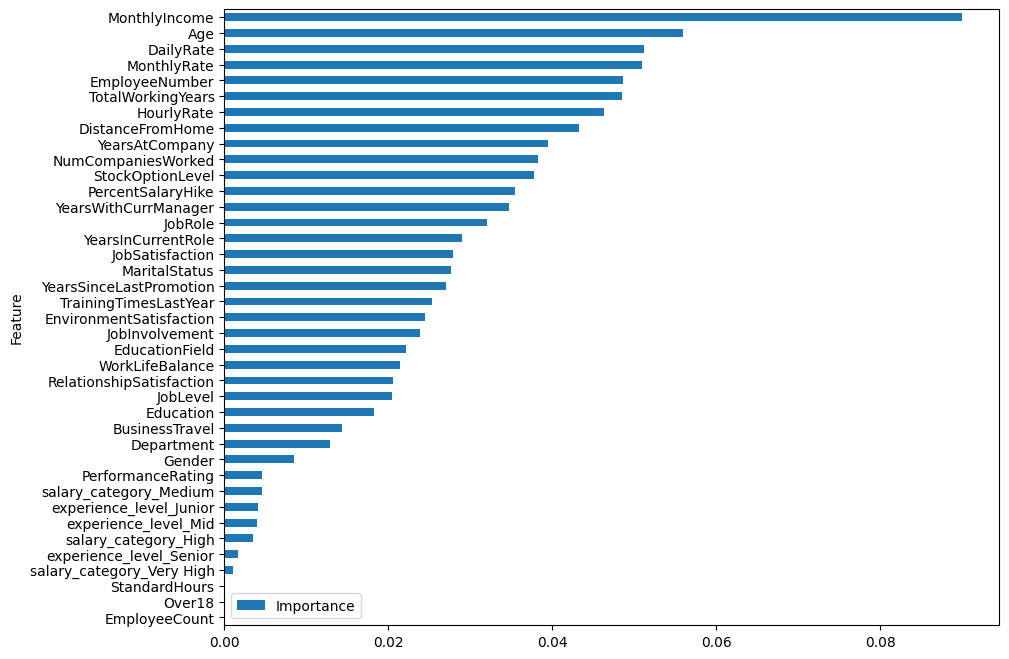

In [98]:
feature_df.sort_values(
    by='Importance',
    ascending=True
).plot(
    x='Feature',
    y='Importance',
    kind='barh',
    figsize=(10,8)
)

plt.show()

In [99]:
from sklearn.metrics import roc_auc_score

prob = rf.predict_proba(X_test)[:,1]

print(roc_auc_score(y_test, prob))

0.6815485168426344


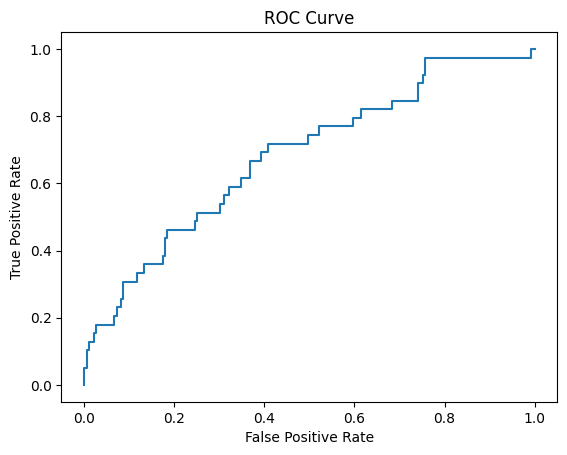

In [100]:
from sklearn.metrics import roc_curve

fpr, tpr, threshold = roc_curve(y_test, prob)

plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

In [101]:
from xgboost import XGBClassifier

xgb = XGBClassifier()

xgb.fit(X_train, y_train)

pred = xgb.predict(X_test)

In [102]:
import joblib

joblib.dump(rf, 'hr_attrition_model.pkl')

['hr_attrition_model.pkl']

In [103]:
import streamlit as st

st.title("HR Attrition Prediction")

age = st.slider("Age",18,60)

salary = st.number_input("Salary")

if st.button("Predict"):
    st.write("Prediction Completed")

2026-05-10 12:05:14.391 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-10 12:05:14.676 
  command:

    streamlit run c:\Users\shali\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-05-10 12:05:14.676 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-10 12:05:14.677 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-10 12:05:14.680 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-10 12:05:14.682 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-10 12:05:14.684 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-10 12:05: